In [1]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# ----- LABEL DISTRIBUTION: Bar chart showing distribution in the training data
# ---------- Only need Excel Sheet for the Label Distribution

# === Paths === 
excel_path = "D:/University/AI/SAND Project/SAND_Challenge_task1_dataset/task1/sand_task_1.xlsx"   
plots_dir = "D:/University/AI/SAND Project/Detecting_Dysarthia/Plots"

# === Create results folder if not exists ===
os.makedirs(plots_dir, exist_ok=True)

# === Load Excel Data ===
df = pd.read_excel(excel_path)

# Expected columns: ['ID', 'Age', 'Sex', 'Class'] 
print("Columns found:", df.columns.tolist())

# === Check class distribution ===
label_counts = df['Class'].value_counts().sort_index()

# === Map class numbers to meaningful names ===
class_labels = {
    1: "ALS - Severe Dysarthria",
    2: "ALS - Moderate Dysarthria",
    3: "ALS - Mild Dysarthria",
    4: "ALS - No Dysarthria",
    5: "Healthy"
}

Columns found: ['ID', 'Age', 'Sex', 'Class']


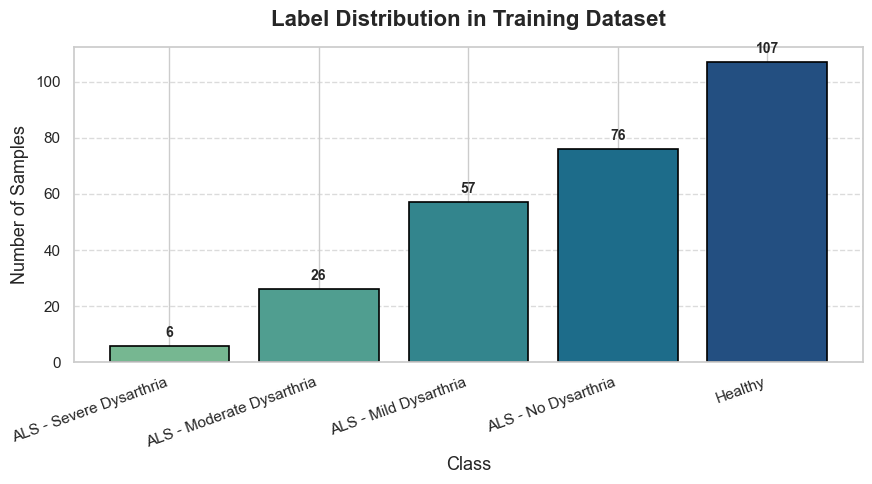

✅ Figure saved successfully at: plots\label_distribution.pdf


In [3]:
# -------- PLOT
# Ensure the results folder exists
os.makedirs("plots", exist_ok=True)

sns.set_theme(style="whitegrid")

plt.figure(figsize=(9, 5))
bars = plt.bar(
    label_counts.index.map(class_labels),
    label_counts.values,
    color=sns.color_palette("crest", n_colors=len(label_counts)),
    edgecolor="black",
    linewidth=1.2
)

plt.title("Label Distribution in Training Dataset", fontsize=16, weight="bold", pad=15)
plt.xlabel("Class", fontsize=13)
plt.ylabel("Number of Samples", fontsize=13)
plt.xticks(rotation=20, ha='right', fontsize=11)
plt.yticks(fontsize=11)
plt.grid(axis="y", linestyle="--", alpha=0.7)

# Add value labels on top of each bar
for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        height + max(label_counts.values)*0.02,
        f"{int(height)}",
        ha="center",
        va="bottom",
        fontsize=10,
        weight="semibold"
    )

plt.tight_layout()

# === Save as pdf ===
# Save before showing
save_path = os.path.join("plots", "label_distribution.pdf")
plt.savefig(save_path, dpi=300, bbox_inches='tight')
plt.show()

print(f"✅ Figure saved successfully at: {save_path}")
